# UK Biobank model evaluation plots (before fine-tuning)

This notebook contains:

1. `model_df`: the model comparison summary dataframe  
2. `agreement_df`: the pairwise agreement dataframe  
3. A pairwise agreement heatmap **without numeric annotations**  
4. An F1-score comparison plot across models


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Model summary dataframe
model_df = pd.DataFrame([
    {"model":"zephyr","type":"LLM","total_time_s":406.045986,"items_per_sec":3.078469,"json_parse_rate":1.0,"id_echo_rate":0.9992,"n_used":1250,"accuracy":0.4472,"precision":1.000000,"recall":0.309,"f1":0.472116,"tp":309,"tn":250,"fp":0,"fn":691,"threshold":np.nan,"calib_best_f1":np.nan},
    {"model":"llama3","type":"LLM","total_time_s":368.310285,"items_per_sec":3.393878,"json_parse_rate":1.0,"id_echo_rate":1.0000,"n_used":1250,"accuracy":0.8864,"precision":1.000000,"recall":0.858,"f1":0.923574,"tp":858,"tn":250,"fp":0,"fn":142,"threshold":np.nan,"calib_best_f1":np.nan},
    {"model":"mistral","type":"LLM","total_time_s":320.088859,"items_per_sec":3.905166,"json_parse_rate":1.0,"id_echo_rate":0.9456,"n_used":1250,"accuracy":0.8832,"precision":1.000000,"recall":0.854,"f1":0.921251,"tp":854,"tn":250,"fp":0,"fn":146,"threshold":np.nan,"calib_best_f1":np.nan},
    {"model":"phi3","type":"LLM","total_time_s":324.421100,"items_per_sec":3.853017,"json_parse_rate":1.0,"id_echo_rate":0.9960,"n_used":1250,"accuracy":0.8800,"precision":0.998826,"recall":0.851,"f1":0.919006,"tp":851,"tn":249,"fp":1,"fn":149,"threshold":np.nan,"calib_best_f1":np.nan},
    {"model":"scibert","type":"Encoder","total_time_s":3.941525,"items_per_sec":317.136101,"json_parse_rate":np.nan,"id_echo_rate":np.nan,"n_used":1250,"accuracy":0.8024,"precision":0.801925,"recall":1.000,"f1":0.890076,"tp":1000,"tn":3,"fp":247,"fn":0,"threshold":0.163775,"calib_best_f1":0.890869},
    {"model":"sbert","type":"Encoder","total_time_s":1.226755,"items_per_sec":1018.948537,"json_parse_rate":np.nan,"id_echo_rate":np.nan,"n_used":1250,"accuracy":0.8888,"precision":0.917556,"recall":0.946,"f1":0.931561,"tp":946,"tn":165,"fp":85,"fn":54,"threshold":0.139915,"calib_best_f1":0.945274},
])

model_df

,model,type,total_time_s,items_per_sec,json_parse_rate,id_echo_rate,n_used,accuracy,precision,recall,f1,tp,tn,fp,fn,threshold,calib_best_f1
0,zephyr,LLM,406.045986,3.078469,1.0,0.9992,1250,0.4472,1.000000,0.309,0.472116,309,250,0,691,NaN,NaN
1,llama3,LLM,368.310285,3.393878,1.0,1.0000,1250,0.8864,1.000000,0.858,0.923574,858,250,0,142,NaN,NaN
2,mistral,LLM,320.088859,3.905166,1.0,0.9456,1250,0.8832,1.000000,0.854,0.921251,854,250,0,146,NaN,NaN
3,phi3,LLM,324.421100,3.853017,1.0,0.9960,1250,0.8800,0.998826,0.851,0.919006,851,249,1,149,NaN,NaN
4,scibert,Encoder,3.941525,317.136101,NaN,NaN,1250,0.8024,0.801925,1.000,0.890076,1000,3,247,0,0.163775,0.890869
5,sbert,Encoder,1.226755,1018.948537,NaN,NaN,1250,0.8888,0.917556,0.946,0.931561,946,165,85,54,0.139915,0.945274


In [8]:
# Pairwise agreement dataframe (%)
agreement_df = pd.DataFrame(
    [[100.0,56.1,56.4,56.4,25.0,40.6],
     [56.1,100.0,98.6,97.3,68.9,83.1],
     [56.4,98.6,100.0,97.6,68.6,82.6],
     [56.4,97.3,97.6,100.0,68.4,82.8],
     [25.0,68.9,68.6,68.4,100.0,82.2],
     [40.6,83.1,82.6,82.8,82.2,100.0]],
    index=["zephyr","llama3","mistral","phi3","scibert","sbert"],
    columns=["zephyr","llama3","mistral","phi3","scibert","sbert"]
)

agreement_df

,zephyr,llama3,mistral,phi3,scibert,sbert
zephyr,100.0,56.1,56.4,56.4,25.0,40.6
llama3,56.1,100.0,98.6,97.3,68.9,83.1
mistral,56.4,98.6,100.0,97.6,68.6,82.6
phi3,56.4,97.3,97.6,100.0,68.4,82.8
scibert,25.0,68.9,68.6,68.4,100.0,82.2
sbert,40.6,83.1,82.6,82.8,82.2,100.0


## Pairwise agreement heatmap



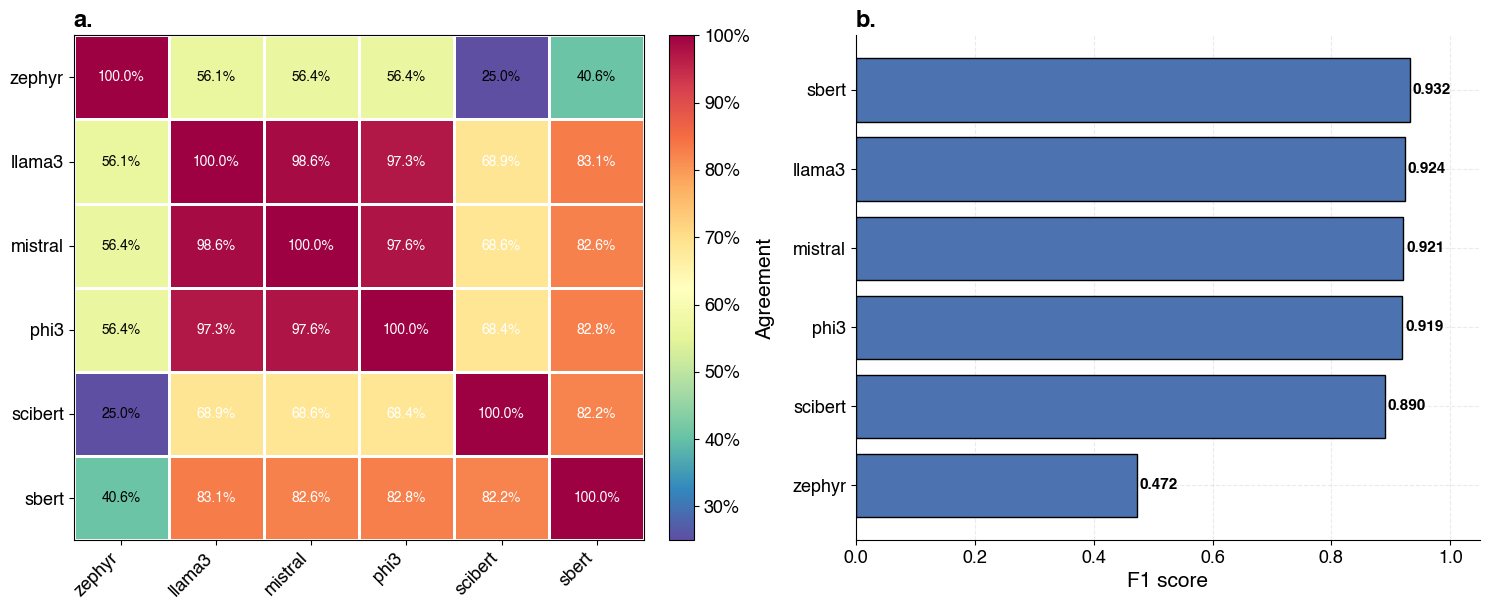

In [9]:
# Combined figure: agreement heatmap + F1 bar chart (patents-style typography)
plt.rcParams['font.family'] = 'Helvetica'

title_fontsize = 17
label_fontsize = 15
tick_fontsize = 13
annot_fontsize = 11

plot_df = model_df.sort_values("f1", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

# (a) Pairwise agreement heatmap
ax = axes[0]
heat_values = agreement_df.values.astype(float)
heat_vmin = float(np.nanmin(heat_values))
heat_vmax = float(np.nanmax(heat_values))

im = ax.pcolormesh(
    heat_values,
    cmap='Spectral_r',
    vmin=heat_vmin,
    vmax=heat_vmax,
    edgecolors='white',
    linewidth=0.8,
    shading='auto',
)

ax.set_xticks(np.arange(len(agreement_df.columns)) + 0.5)
ax.set_yticks(np.arange(len(agreement_df.index)) + 0.5)
ax.set_xticklabels(agreement_df.columns, rotation=45, ha='right')
ax.set_yticklabels(agreement_df.index)
ax.set_ylim(len(agreement_df.index), 0)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.set_title('a.', fontsize=title_fontsize, fontweight='bold', loc='left')

threshold = (heat_vmin + heat_vmax) / 2
for i in range(heat_values.shape[0]):
    for j in range(heat_values.shape[1]):
        v = heat_values[i, j]
        text_color = 'white' if v >= threshold else 'black'
        ax.text(j + 0.5, i + 0.5, f"{v:.1f}%", ha='center', va='center', color=text_color, fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Agreement', fontsize=label_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)
from matplotlib.ticker import FuncFormatter
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))

# (b) F1-score comparison
ax = axes[1]
ax.barh(plot_df['model'], plot_df['f1'], color='#4C72B0', edgecolor='black', linewidth=1)
for i, v in enumerate(plot_df['f1']):
    ax.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=annot_fontsize, fontweight='bold')

ax.set_xlabel('F1 score', fontsize=label_fontsize)
ax.set_ylabel('', fontsize=label_fontsize)
ax.set_title('b.', fontsize=title_fontsize, fontweight='bold', loc='left')
ax.set_xlim(0, 1.05)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.set_axisbelow(True)
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
from pathlib import Path
out_dir = Path('../fig')
out_dir.mkdir(parents=True, exist_ok=True)
out_base = out_dir / 'mingyue_ukb_model_plots'
for ext in ('png', 'pdf', 'svg'):
    fig.savefig(out_base.with_suffix(f'.{ext}'), dpi=800 if ext == 'png' else None, bbox_inches='tight')
plt.show()



## F1-score comparison across models

In [10]:
# Plot included above in the combined side-by-side figure.
